# Descriptive Analysis for LitBench Dataset

**Dataset:** https://huggingface.co/collections/SAA-Lab/litbench
- 43.827 pairwise examples with human preference labels
- Based on WritingPrompts dataset
- Preferences via Upvotes


In [13]:
# Load packages
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Load data

In [14]:
ds = load_dataset('SAA-Lab/LitBench-Train', split='train')
df = ds.to_pandas()

print(f'LitBench geladen: {len(df):,} Paare')
print(f'Spalten: {list(df.columns)}')
print(f'\nBeispiel:')
print(f'  Prompt:  "{df.iloc[0]["prompt"][:100]}..."')
print(f'  Chosen:  {len(df.iloc[0]["chosen_story"]):,} chars, {df.iloc[0]["chosen_upvotes"]} upvotes')
print(f'  Rejected: {len(df.iloc[0]["rejected_story"]):,} chars, {df.iloc[0]["rejected_upvotes"]} upvotes')

LitBench geladen: 43,827 Paare
Spalten: ['prompt', 'chosen_story', 'rejected_story', 'chosen_timestamp', 'rejected_timestamp', 'chosen_upvotes', 'rejected_upvotes']

Beispiel:
  Prompt:  "[WP] In this world, soulmates cannot hurt each other in any way or form, intentionally or unintentio..."
  Chosen:  389 chars, 102 upvotes
  Rejected: 8,116 chars, 22 upvotes


## Dataset Overview

Pairs:          43,827
Unique Prompts: 12,419

Chosen  Story Length: mean=2997, median=2718
Rejected Story Length: mean=2992, median=2640

Upvote Ratio (chosen/rejected): mean=7.5, median=2.7


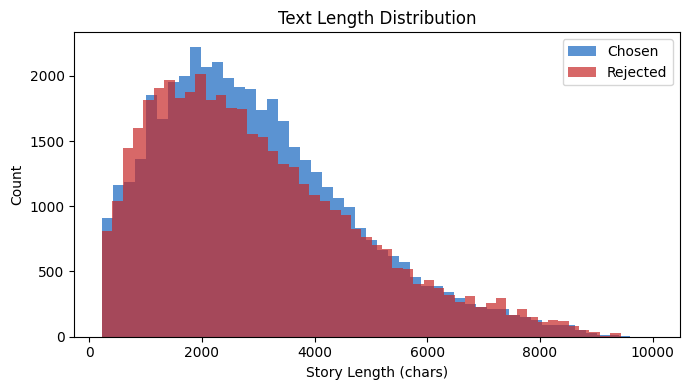

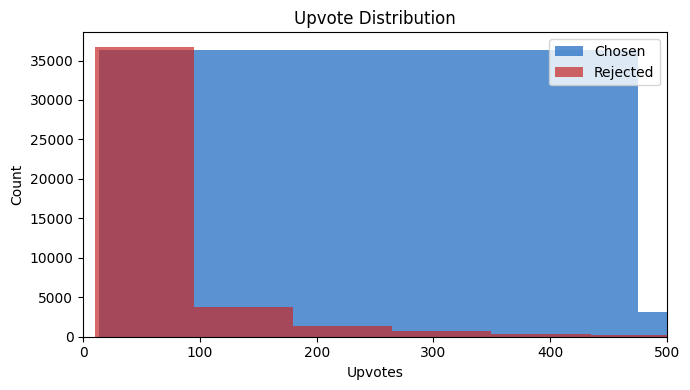

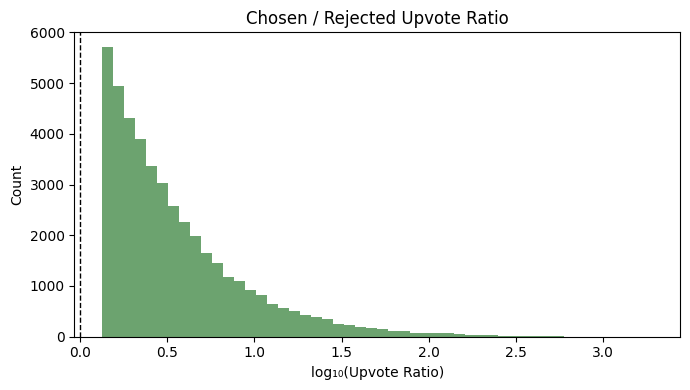

In [15]:
df['chosen_len'] = df['chosen_story'].str.len()
df['rejected_len'] = df['rejected_story'].str.len()
df['upvote_ratio'] = df['chosen_upvotes'] / df['rejected_upvotes'].clip(lower=1)
df['prompt_len'] = df['prompt'].str.len()

print(f'Pairs:          {len(df):,}')
print(f'Unique Prompts: {df["prompt"].nunique():,}')
print(f'\nChosen  Story Length: mean={df["chosen_len"].mean():.0f}, median={df["chosen_len"].median():.0f}')
print(f'Rejected Story Length: mean={df["rejected_len"].mean():.0f}, median={df["rejected_len"].median():.0f}')
print(f'\nUpvote Ratio (chosen/rejected): mean={df["upvote_ratio"].mean():.1f}, median={df["upvote_ratio"].median():.1f}')

# Text length
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['chosen_len'], bins=50, alpha=0.7, label='Chosen', color='#1565C0')
ax.hist(df['rejected_len'], bins=50, alpha=0.7, label='Rejected', color='#C62828')
ax.set_xlabel('Story Length (chars)')
ax.set_ylabel('Count')
ax.set_title('Text Length Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('figures/data_description/litbench_text_length.png', bbox_inches='tight')
plt.show()

# Upvote distribution
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['chosen_upvotes'], bins=50, alpha=0.7, color='#1565C0', label='Chosen')
ax.hist(df['rejected_upvotes'], bins=50, alpha=0.7, color='#C62828', label='Rejected')
ax.set_xlabel('Upvotes')
ax.set_ylabel('Count')
ax.set_title('Upvote Distribution')
ax.set_xlim(0, 500)
ax.legend()
plt.tight_layout()
plt.savefig('figures/data_description/litbench_upvote_distribution.png', bbox_inches='tight')
plt.show()

# Upvote ratio
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log10(df['upvote_ratio'].clip(lower=0.1)), bins=50, color='#2E7D32', alpha=0.7)
ax.set_xlabel('log₁₀(Upvote Ratio)')
ax.set_ylabel('Count')
ax.set_title('Chosen / Rejected Upvote Ratio')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('figures/data_description/litbench_upvote_ratio.png', bbox_inches='tight')
plt.show()

1. If "better" texts (more upvotes) aren't systematically longer or shorter
2. Distribution is skewed to the right -> most texts have few upvotes and some have a lot
3. A lot of pairs are close to zero -> Upvote-Differences are minimal

## Preference Signal Quality

Pairs surviving upvote-margin thresholds (chosen - rejected >= threshold):
  >=   1: 43,827 (100.0%)
  >=   5: 43,282 (98.8%)
  >=  10: 39,293 (89.7%)
  >=  20: 32,963 (75.2%)
  >=  50: 23,134 (52.8%)

Upvote difference: mean=304.1, median=56, min=4, max=23067


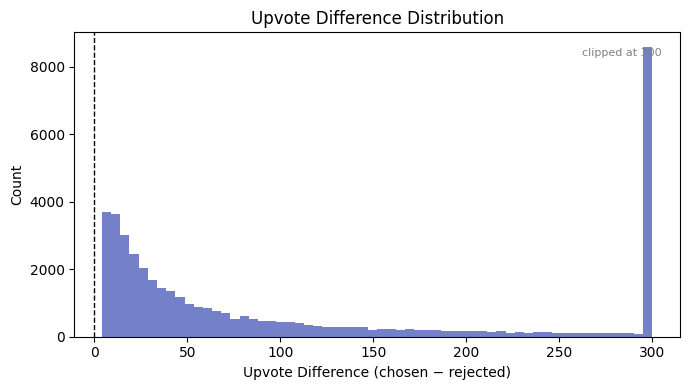

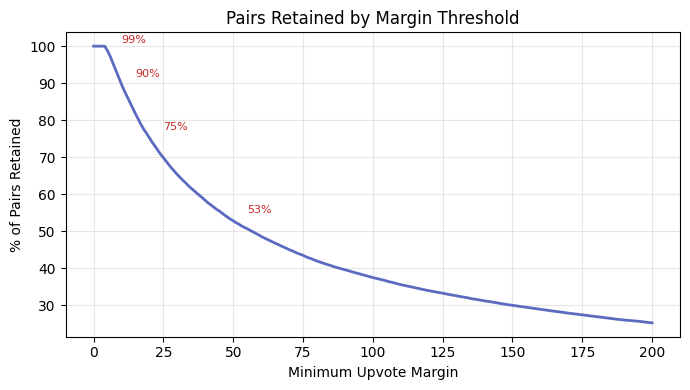

In [16]:
df['upvote_diff'] = df['chosen_upvotes'] - df['rejected_upvotes']

# Share of pairs per margin threshold
thresholds = [1, 5, 10, 20, 50]
print("Pairs surviving upvote-margin thresholds (chosen - rejected >= threshold):")
for t in thresholds:
    n = (df['upvote_diff'] >= t).sum()
    print(f"  >= {t:>3}: {n:,} ({n/len(df)*100:.1f}%)")

print(f"\nUpvote difference: mean={df['upvote_diff'].mean():.1f}, median={df['upvote_diff'].median():.0f}, "
      f"min={df['upvote_diff'].min()}, max={df['upvote_diff'].max()}")

# Distribution of upvote differences
clip_val = 300
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['upvote_diff'].clip(upper=clip_val), bins=60, color='#5C6BC0', alpha=0.85)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Upvote Difference (chosen − rejected)')
ax.set_ylabel('Count')
ax.set_title('Upvote Difference Distribution')
ax.annotate(f'clipped at {clip_val}', xy=(0.97, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('figures/data_description/litbench_upvote_diff.png', bbox_inches='tight')
plt.show()

# Cumulative share of pairs surviving each margin threshold
margins = range(0, 201)
survival = [(df['upvote_diff'] >= m).mean() * 100 for m in margins]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(margins, survival, color='#5C6BC0', linewidth=2)
ax.set_xlabel('Minimum Upvote Margin')
ax.set_ylabel('% of Pairs Retained')
ax.set_title('Pairs Retained by Margin Threshold')
ax.grid(True, alpha=0.3)
for t in [5, 10, 20, 50]:
    pct = (df['upvote_diff'] >= t).mean() * 100
    ax.annotate(f'{pct:.0f}%', xy=(t, pct), xytext=(t + 5, pct + 2),
                fontsize=8, color='#C62828')
plt.tight_layout()
plt.savefig('figures/data_description/litbench_margin_survival.png', bbox_inches='tight')
plt.show()

4. Quite a few pairs with difference close to 0 -> ambivalent decision
5. How many pairs are left if we expect a certain minimal treshold

## Text Structure

Word count — chosen vs rejected:
  Chosen:   mean=540, median=491
  Rejected: mean=542, median=478

Length ratio (chosen / rejected): mean=1.43, median=1.00
Longer story preferred: 49.6% of pairs

Correlation (word count ↔ upvotes):
  Chosen:   r = 0.060
  Rejected: r = 0.069


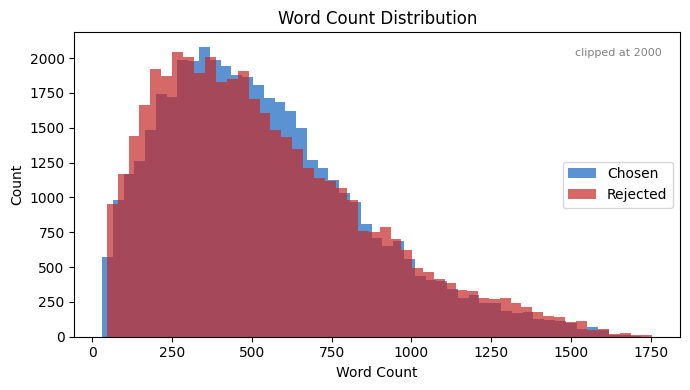

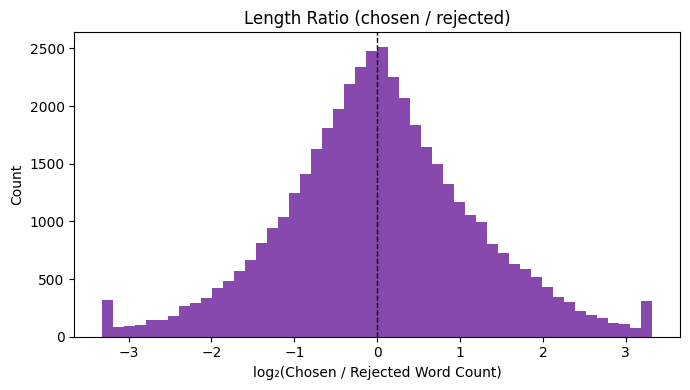

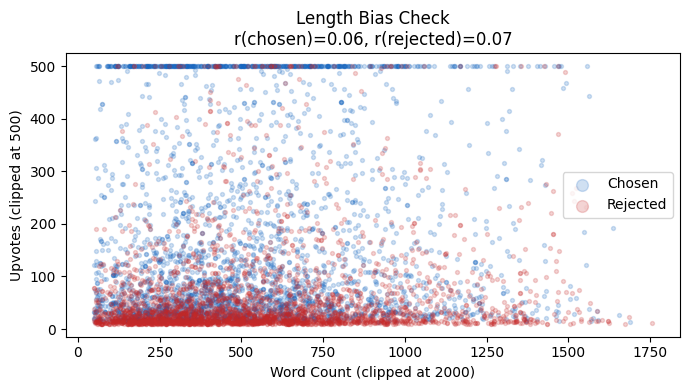

In [17]:
df['chosen_words'] = df['chosen_story'].str.split().str.len()
df['rejected_words'] = df['rejected_story'].str.split().str.len()
df['len_ratio'] = df['chosen_words'] / df['rejected_words'].clip(lower=1)
# Flag whether the longer story was preferred
df['longer_preferred'] = df['chosen_words'] > df['rejected_words']

print("Word count — chosen vs rejected:")
print(f"  Chosen:   mean={df['chosen_words'].mean():.0f}, median={df['chosen_words'].median():.0f}")
print(f"  Rejected: mean={df['rejected_words'].mean():.0f}, median={df['rejected_words'].median():.0f}")
print(f"\nLength ratio (chosen / rejected): mean={df['len_ratio'].mean():.2f}, median={df['len_ratio'].median():.2f}")
print(f"Longer story preferred: {df['longer_preferred'].mean()*100:.1f}% of pairs")

# Pearson correlations: word count vs upvotes
corr_chosen  = df['chosen_words'].corr(df['chosen_upvotes'])
corr_rejected = df['rejected_words'].corr(df['rejected_upvotes'])
print(f"\nCorrelation (word count ↔ upvotes):")
print(f"  Chosen:   r = {corr_chosen:.3f}")
print(f"  Rejected: r = {corr_rejected:.3f}")

# Word count distributions
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['chosen_words'].clip(upper=2000), bins=50, alpha=0.7, label='Chosen', color='#1565C0')
ax.hist(df['rejected_words'].clip(upper=2000), bins=50, alpha=0.7, label='Rejected', color='#C62828')
ax.set_xlabel('Word Count')
ax.set_ylabel('Count')
ax.set_title('Word Count Distribution')
ax.legend()
ax.annotate('clipped at 2000', xy=(0.97, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('figures/data_description/litbench_word_count.png', bbox_inches='tight')
plt.show()

# Length ratio
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log2(df['len_ratio'].clip(0.1, 10)), bins=50, color='#6A1B9A', alpha=0.8)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('log₂(Chosen / Rejected Word Count)')
ax.set_ylabel('Count')
ax.set_title('Length Ratio (chosen / rejected)')
plt.tight_layout()
plt.savefig('figures/data_description/litbench_length_ratio.png', bbox_inches='tight')
plt.show()

# Length bias: scatter word count vs upvotes
sample = df.sample(3000, random_state=42)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(sample['chosen_words'].clip(upper=2000), sample['chosen_upvotes'].clip(upper=500),
           alpha=0.2, s=8, color='#1565C0', label='Chosen')
ax.scatter(sample['rejected_words'].clip(upper=2000), sample['rejected_upvotes'].clip(upper=500),
           alpha=0.2, s=8, color='#C62828', label='Rejected')
ax.set_xlabel('Word Count (clipped at 2000)')
ax.set_ylabel('Upvotes (clipped at 500)')
ax.set_title(f'Length Bias Check\nr(chosen)={corr_chosen:.2f}, r(rejected)={corr_rejected:.2f}')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('figures/data_description/litbench_length_bias.png', bbox_inches='tight')
plt.show()

6. BEtter texts aren't systematically shorter or longer
7. Symmetrically around 0 -> no length-bias
8. No correlation between length and upvotes